# Relative Abundance of WS/DGAT Biosynthetic Potential in Terrestrial Sediment Metagenomes

**Author:** Virginia Galván, PhD
**Associated publication / thesis reference:** doctoral thesis, Chapter I — Section 7.3.7, Figure 14

---

## Biological context

Notebook 04 showed that WS/DGAT biosynthetic potential (Pfam domain **PF03007**) is not a local peculiarity of the original polluted-sediment site, but a recurring feature across 101 marine sediment metagenomes worldwide. Most previously characterized WS/DGAT enzymes come from soil-dwelling organisms (*A. baylyi* ADP1, *R. opacus* PD630, *R. jostii* RHA1, *S. coelicolor* A3(2), *S. avermitilis* MA-4680, *T. curvata*, *Streptomyces* sp. G25), with marine representatives described to a lesser extent (*Marinobacter hydrocarbonoclasticus*, *M. aquaeolei* VT8, *Alkanivorax borkumensis* SK2).

This notebook asks the converse question: does the same biosynthetic potential hold up in terrestrial sediments, where most of the known enzymes actually originate? It surveys **227 terrestrial sediment metagenomes** from the IMG/M database and, in Section 4, formally compares the result against the marine survey from Notebook 04.

## 0. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu

# Path configuration: works whether the notebook is run from the repo's
# notebooks/ folder (data/ one level up) or from the same directory as the data files
DATA_DIR = '../data' if os.path.exists('../data') else '.'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150
})

# Relative-abundance tiers, consistent across the WS/DGAT notebook series
ABUNDANCE_COLORS = {
    'low': '#c6dbef',       # mean_ratio <= 1
    'medium': '#4292c6',    # 1 < mean_ratio <= 2
    'high': '#08306b'       # mean_ratio > 2
}

print(f'Data directory: {DATA_DIR}')

Data directory: .


## 1. Load and process data

**Pfam domains used (13 total):**
- Target: **PF03007** (WS/DGAT — putative neutral lipid biosynthesis gene)
- Reference: 12 single-copy ribosomal protein domains (PF00189, PF00252, PF00453, PF00542, PF00831, PF00886, PF01016, PF01196, PF01245, PF01250, PF01281, PF01649), used to normalize for differences in metagenome size and sequencing depth (same approach as Notebooks 01 and 04).

**Data source:** Pfam domain hit counts were retrieved from IMG/M for 227 terrestrial sediment metagenomes (filtered by ecosystem type = terrestrial sediment; IMG/M query, October 2025). Study Name, ecosystem classification, geographic coordinates, and estimated CDS count were exported from the same database.

In [2]:
gene_counts = pd.read_csv(f'{DATA_DIR}/terrestrial_metagenomes_gene_counts_repo1.csv', index_col='metagenome_id')
metadata = pd.read_csv(f'{DATA_DIR}/terrestrial_metagenomes_metadata_repo1.csv')

print(f'Gene counts table: {gene_counts.shape[0]} metagenomes x {gene_counts.shape[1]} Pfam domains')
print(f'Metadata table: {metadata.shape[0]} metagenomes')
gene_counts.head()

Gene counts table: 227 metagenomes x 13 Pfam domains
Metadata table: 227 metagenomes


,pfam03007,pfam00189,pfam00252,pfam00453,pfam00542,pfam00831,pfam00886,pfam01016,pfam01196,pfam01245,pfam01250,pfam01281,pfam01649
metagenome_id,,,,,,,,,,,,,
3300044783,161,229,277,224,212,215,193,223,263,238,184,190,200
3300005147,48,45,77,65,50,44,45,41,63,64,48,40,34
3300025322,230,639,735,573,566,586,513,547,629,585,576,460,509
3300044495,106,264,314,251,204,228,185,225,262,259,208,178,200
3300053049,117,229,248,225,184,223,208,195,204,220,196,213,194


### 1.1 Compute relative abundance

Relative abundance of PF03007 in each metagenome is the **mean of 12 ratios** (PF03007 count / each ribosomal marker count) — identical methodology to Notebooks 01 and 04. `n_valid` tracks how many of the 12 ratios were computable (a ribosomal marker with zero hits produces an undefined ratio, recorded as `NaN`).

**QC threshold:** a metagenome is retained only if at least 6 of its 12 ratios are valid (i.e. no more than half of the reference ribosomal markers are undetected) — the same threshold applied throughout this portfolio, for consistency across surveys.

In [3]:
pfam_target = 'pfam03007'
pfams_ref = [c for c in gene_counts.columns if c != pfam_target]

ratios = pd.DataFrame(index=gene_counts.index)
numerator = gene_counts[pfam_target].astype(float)

for ref in pfams_ref:
    with np.errstate(divide='ignore', invalid='ignore'):
        r = numerator / gene_counts[ref].astype(float)
        r = r.replace([np.inf, -np.inf], np.nan)
    ratios[f'ratio_over_{ref}'] = r

ratios['mean_ratio'] = ratios.mean(axis=1, skipna=True)
ratios['std_ratio'] = ratios.std(axis=1, ddof=1, skipna=True)
ratios['n_valid'] = ratios.iloc[:, :len(pfams_ref)].notna().sum(axis=1)

MIN_VALID_RATIOS = 6
n_failed_qc = (ratios['n_valid'] < MIN_VALID_RATIOS).sum()
print(f'Metagenomes failing QC (n_valid < {MIN_VALID_RATIOS}/12): {n_failed_qc}')

ratios = ratios[ratios['n_valid'] >= MIN_VALID_RATIOS]
df = gene_counts.join(ratios[['mean_ratio', 'std_ratio', 'n_valid']], how='inner').join(
    metadata.set_index('metagenome_id')
)
print(f'Metagenomes passing QC: {df.shape[0]} / {gene_counts.shape[0]}')

df['abundance_tier'] = pd.cut(
    df['mean_ratio'], bins=[-np.inf, 1, 2, np.inf], labels=['low', 'medium', 'high']
)
df = df.sort_values('mean_ratio').reset_index()
df['rank'] = np.arange(1, len(df) + 1)
df.head()

Metagenomes failing QC (n_valid < 6/12): 17
Metagenomes passing QC: 210 / 227


,metagenome_id,pfam03007,pfam00189,pfam00252,pfam00453,pfam00542,pfam00831,pfam00886,pfam01016,pfam01196,...,n_valid,study_name,ecosystem_subtype,specific_ecosystem,geographic_location,latitude,longitude,cds_count,abundance_tier,rank
0,3300002189,0,1,1,1,1,1,1,1,1,...,12,Enriched soil microbial communities from the U...,Sediment,Pyrite containing,"Hanford Site, Washington, USA",46.547528,-119.521866,6392,low,1
1,3300001133,0,8,10,7,7,7,3,4,9,...,12,"Soil microbial communities from Rifle, Colorad...",Rock core/Sediment,Unclassified,"Rifle, Colorado, USA",39.530000,-107.780000,38526,low,2
2,3300032140,0,1,2,1,1,1,2,1,2,...,12,Deep subsurface sediment microbial communities...,Sediment,Unclassified,Pacific Ocean: Tonga Trench,-16.641750,-172.200017,12909,low,3
3,3300001911,0,5,4,4,4,5,6,6,5,...,12,Enriched soil microbial communities from the U...,Sediment,Pyrite containing,"Hanford Site, Washington, USA",46.547528,-119.521866,37584,low,4
4,3300002246,0,1,1,1,1,1,1,1,1,...,12,Enriched soil microbial communities from the U...,Sediment,Pyrite containing,"Hanford Site, Washington, USA",46.547528,-119.521866,6238,low,5


## 2. Figure 3 — Relative WS/DGAT abundance ranked across terrestrial metagenomes

Same visual convention as Notebooks 01 and 04: mean ± SD of the 12 marker ratios per metagenome, colored by abundance tier, dashed line at y = 1 marking parity with the average single-copy ribosomal gene.

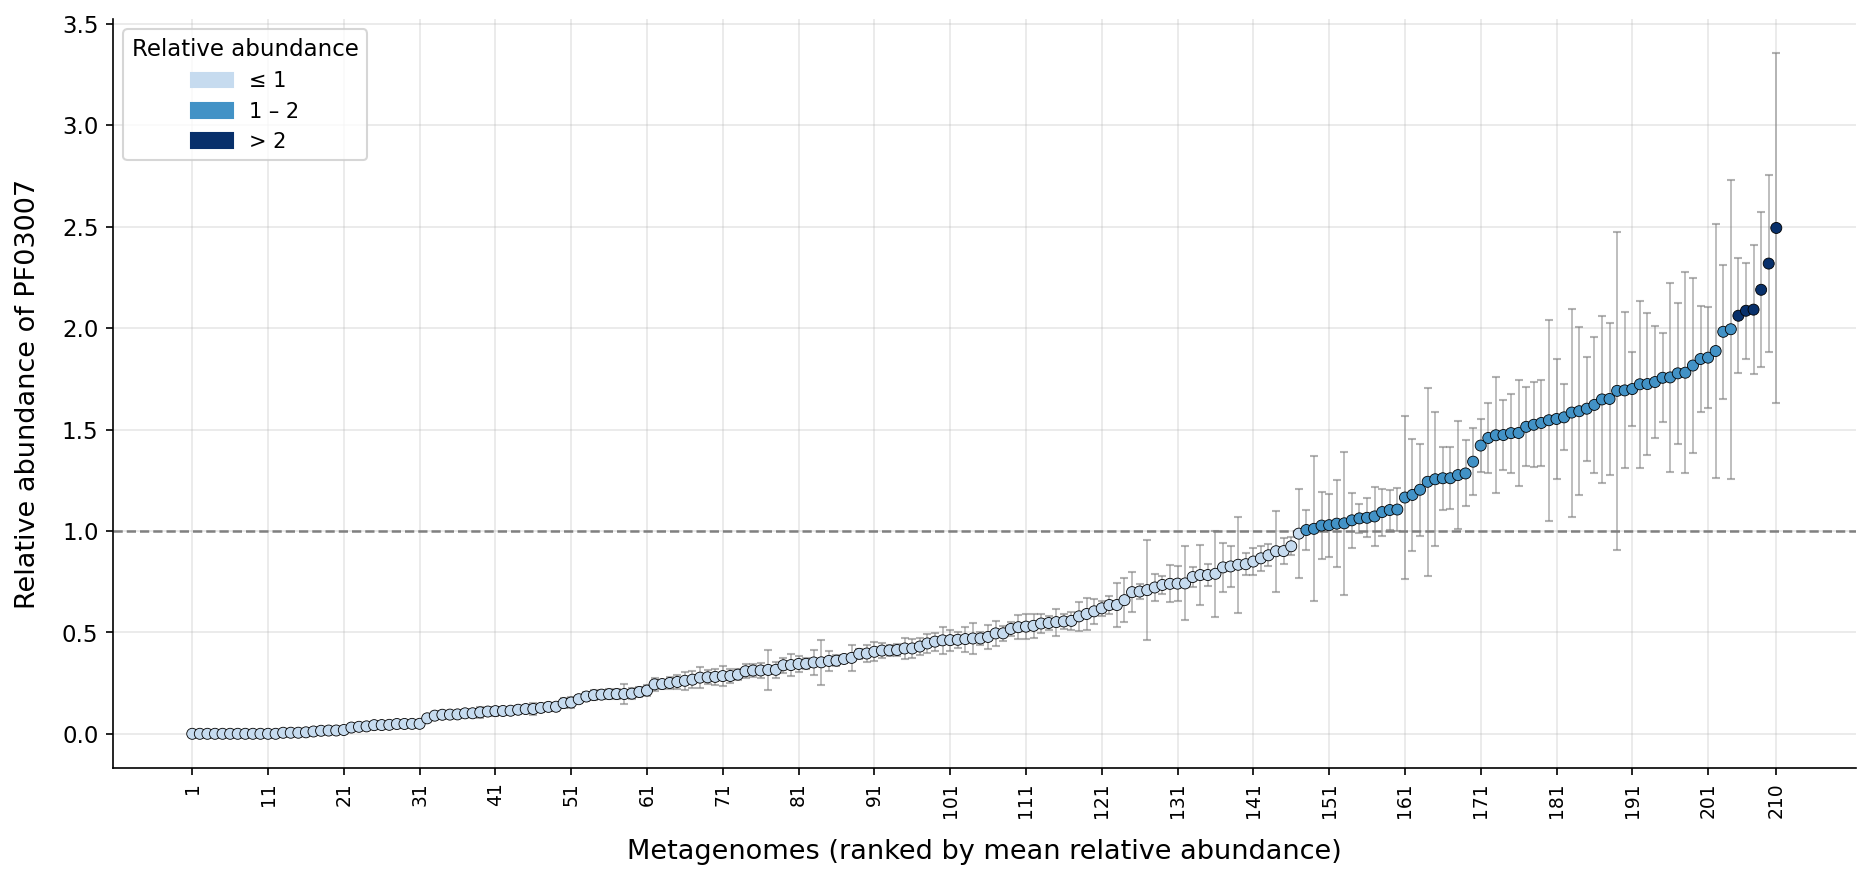


Metagenomes with mean relative abundance > 1: 63/210 (30.00%)
Metagenomes with mean relative abundance > 2: 6/210 (2.86%)


In [4]:
n_points = len(df)
x = np.arange(n_points)
colors = df['abundance_tier'].map(ABUNDANCE_COLORS)

fig_width = max(12, n_points * 0.06)
plt.figure(figsize=(fig_width, 6))

plt.errorbar(x, df['mean_ratio'], yerr=df['std_ratio'], fmt='none',
             capsize=2, elinewidth=0.8, ecolor='gray', alpha=0.6)
plt.scatter(x, df['mean_ratio'], c=colors, s=28, edgecolor='black', linewidth=0.4, zorder=3)

tick_freq = 10
tick_idx = list(np.arange(0, n_points, tick_freq))
if tick_idx[-1] != n_points - 1:
    tick_idx.append(n_points - 1)
plt.xticks(tick_idx, df['rank'].iloc[tick_idx], rotation=90, fontsize=9)

plt.axhline(1, color='gray', linestyle='--', linewidth=1.2)
plt.xlabel('Metagenomes (ranked by mean relative abundance)', fontsize=13, labelpad=10)
plt.ylabel('Relative abundance of PF03007', fontsize=13, labelpad=10)
plt.tick_params(axis='y', labelsize=11)

legend_handles = [
    mpatches.Patch(color=ABUNDANCE_COLORS['low'], label='≤ 1'),
    mpatches.Patch(color=ABUNDANCE_COLORS['medium'], label='1 – 2'),
    mpatches.Patch(color=ABUNDANCE_COLORS['high'], label='> 2'),
]
plt.legend(handles=legend_handles, loc='upper left', frameon=True, fontsize=10, title='Relative abundance')
plt.tight_layout()

plt.savefig(f'{DATA_DIR}/figure3_terrestrial_relative_abundance_ranked.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{DATA_DIR}/figure3_terrestrial_relative_abundance_ranked.svg', bbox_inches='tight')
plt.show()

n_over_1 = (df['mean_ratio'] > 1).sum()
n_over_2 = (df['mean_ratio'] > 2).sum()
print(f'\nMetagenomes with mean relative abundance > 1: {n_over_1}/{n_points} ({n_over_1/n_points*100:.2f}%)')
print(f'Metagenomes with mean relative abundance > 2: {n_over_2}/{n_points} ({n_over_2/n_points*100:.2f}%)')

## 3. Relative abundance by project (Study)

As in Notebook 04, we check whether elevated abundance is a broad pattern or concentrated in a handful of source projects.

In [5]:
study_summary = (
    df.groupby('study_name')
      .agg(n_metagenomes=('mean_ratio', 'size'),
           mean_relative_abundance=('mean_ratio', 'mean'),
           pct_over_1=('mean_ratio', lambda x: (x > 1).mean() * 100))
      .sort_values('n_metagenomes', ascending=False)
      .round(2)
)
study_summary

,n_metagenomes,mean_relative_abundance,pct_over_1
study_name,,,
"Soil microbial communities from Rifle, Colorado, USA",53,0.18,0.00
"Sediment microbial communities from uranium-contaminated floodplain near Riverton, Wyoming, United States",53,0.45,5.66
"Sediment microbial communities from East River floodplain, Colorado, United States",48,1.06,56.25
"Soil and rhizosphere microbial communities from Centre INRS-Institut Armand-Frappier, Laval, Canada",32,1.62,96.88
"Subsurface microbial communities from deep shales in Ohio and West Virginia, USA",12,0.41,8.33
Hydrocarbon resource environments microbial communities from Canada and USA,4,0.86,25.00
"Deep subsurface sediment microbial communities from Tonga Trench, Pacific Ocean",3,0.34,0.00
"Enriched soil microbial communities from the University of Wisconsin-Madison, USA, enriched with a pyrite oxidizing culture",3,0.00,0.00
Microbial communities from the deep biosphere,2,0.05,0.00


**Pattern:** elevated abundance is not evenly distributed across projects. The two largest studies — *Soil microbial communities from Rifle, Colorado* (53 metagenomes) and *Sediment microbial communities from uranium-contaminated floodplain near Riverton, Wyoming* (53 metagenomes) — show almost no elevated abundance (mean ≈ 0.2–0.45, ≤ 6% of metagenomes > 1). In contrast, *Soil and rhizosphere microbial communities from Laval, Canada* (32 metagenomes, deep subsurface rock core) and *Sediment microbial communities from East River floodplain, Colorado* (48 metagenomes) show consistently high relative abundance (mean 1.06–1.62, 56–97% of metagenomes > 1). All 6 metagenomes with mean ratio > 2 come from exactly these two projects.

Unlike the marine survey, where elevated abundance recurred independently across several unrelated projects, the terrestrial signal is concentrated in specific ecosystem types (deep subsurface rock core and floodplain sediment) rather than spread uniformly across terrestrial sediments in general.

## 4. Marine vs. terrestrial: does biosynthetic potential differ by environment?

Most previously characterized WS/DGAT enzymes come from soil organisms, with marine representatives (*Marinobacter*, *Alkanivorax*) described in smaller number, which raises the question of whether terrestrial sediments should show *higher* relative abundance of PF03007 than marine ones. We test this directly by comparing the marine survey (Notebook 04, N = 101) against the terrestrial survey above (N = 210) with a two-sided Mann–Whitney U test (non-parametric, as relative-abundance values are not normally distributed).

Marine metagenomes:      N = 101, median = 0.989
Terrestrial metagenomes: N = 210, median = 0.474

Mann-Whitney U = 13636.0, p = 4.48e-05


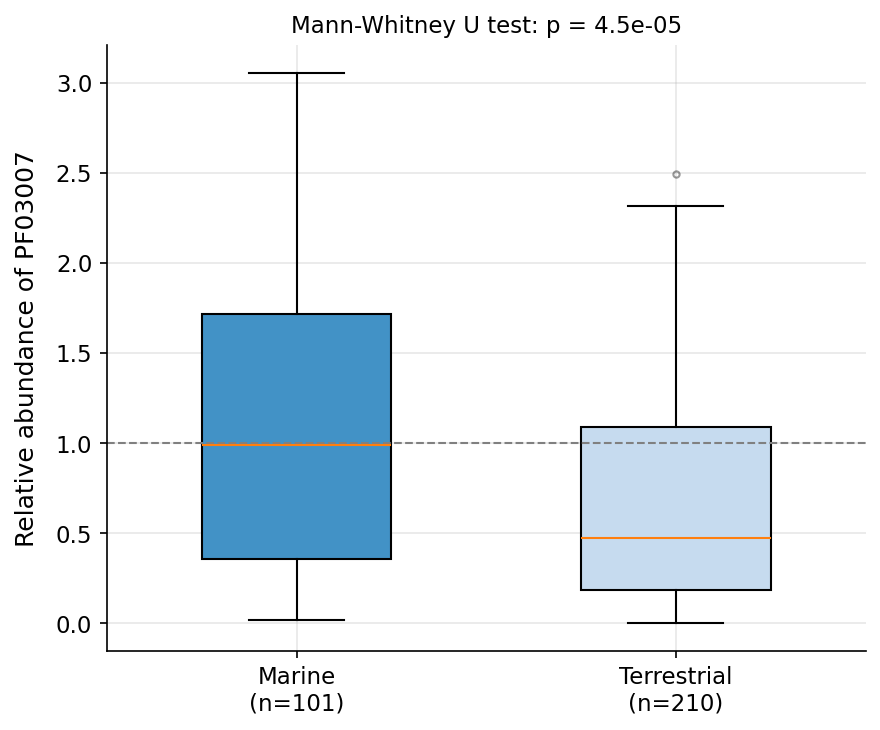

In [6]:
marine_summary = pd.read_csv(f'{DATA_DIR}/global_marine_metagenomes_summary_table.csv')
marine_ratio = marine_summary['Rel. abundance (mean)']
terrestrial_ratio = df['mean_ratio']

u_stat, p_value = mannwhitneyu(marine_ratio, terrestrial_ratio, alternative='two-sided')

print(f'Marine metagenomes:      N = {len(marine_ratio)}, median = {marine_ratio.median():.3f}')
print(f'Terrestrial metagenomes: N = {len(terrestrial_ratio)}, median = {terrestrial_ratio.median():.3f}')
print(f'\nMann-Whitney U = {u_stat:.1f}, p = {p_value:.2e}')

fig, ax = plt.subplots(figsize=(6, 5))
box_data = [marine_ratio.dropna(), terrestrial_ratio.dropna()]
bp = ax.boxplot(box_data, tick_labels=['Marine\n(n=101)', 'Terrestrial\n(n=210)'],
                 patch_artist=True, widths=0.5, showfliers=True,
                 flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, color in zip(bp['boxes'], ['#4292c6', '#c6dbef']):
    patch.set_facecolor(color)
ax.axhline(1, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Relative abundance of PF03007', fontsize=12, labelpad=8)
ax.set_title(f'Mann-Whitney U test: p = {p_value:.1e}', fontsize=11)
plt.tight_layout()

plt.savefig(f'{DATA_DIR}/figure4_marine_vs_terrestrial_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{DATA_DIR}/figure4_marine_vs_terrestrial_comparison.svg', bbox_inches='tight')
plt.show()

**Result:** marine sediment metagenomes show significantly *higher* relative abundance of PF03007 than terrestrial ones (p < 0.0001).

## 5. Export summary table

In [7]:
summary = df[['rank', 'metagenome_id', 'study_name', 'ecosystem_subtype', 'latitude', 'longitude',
              'mean_ratio', 'std_ratio', 'n_valid', 'abundance_tier']].copy()
summary.columns = ['Rank', 'Metagenome ID', 'Study', 'Ecosystem subtype', 'Latitude', 'Longitude',
                    'Rel. abundance (mean)', 'Rel. abundance (SD)', 'N valid ratios', 'Tier']
summary[['Rel. abundance (mean)', 'Rel. abundance (SD)']] = \
    summary[['Rel. abundance (mean)', 'Rel. abundance (SD)']].round(3)

summary.to_csv(f'{DATA_DIR}/terrestrial_metagenomes_summary_table.csv', index=False)
print('Exported: terrestrial_metagenomes_summary_table.csv')
summary.head(10)

Exported: terrestrial_metagenomes_summary_table.csv


,Rank,Metagenome ID,Study,Ecosystem subtype,Latitude,Longitude,Rel. abundance (mean),Rel. abundance (SD),N valid ratios,Tier
0,1,3300002189,Enriched soil microbial communities from the U...,Sediment,46.547528,-119.521866,0.0,0.0,12,low
1,2,3300001133,"Soil microbial communities from Rifle, Colorad...",Rock core/Sediment,39.530000,-107.780000,0.0,0.0,12,low
2,3,3300032140,Deep subsurface sediment microbial communities...,Sediment,-16.641750,-172.200017,0.0,0.0,12,low
3,4,3300001911,Enriched soil microbial communities from the U...,Sediment,46.547528,-119.521866,0.0,0.0,12,low
4,5,3300002246,Enriched soil microbial communities from the U...,Sediment,46.547528,-119.521866,0.0,0.0,12,low
5,6,3300003358,"Soil microbial communities from Rifle, Colorad...",Rock core/Sediment,39.534762,-107.782602,0.0,0.0,12,low
6,7,3300003343,"Soil microbial communities from Rifle, Colorad...",Rock core/Sediment,39.534762,-107.782602,0.0,0.0,12,low
7,8,3300028034,Subsurface microbial communities from deep sha...,Rock core/Sediment,39.601700,-79.976100,0.0,0.0,12,low
8,9,3300031929,Microbial communities from the deep biosphere,Sediment,-16.641750,-172.200017,0.0,0.0,9,low
9,10,3300002502,"Soil microbial communities from Rifle, Colorad...",Rock core/Sediment,39.534762,-107.782602,0.0,0.0,12,low


- Galván V. et al. (2023). High potential for the biosynthesis of neutral lipid storage compounds in chronically-polluted subantarctic sediments. *PLOS ONE*, 18(7). https://doi.org/10.1371/journal.pone.0288509
- Chen IA, Chu K, Palaniappan K, et al. (2021). The IMG/M data management and analysis system v.6.0: new tools and advanced capabilities. *Nucleic Acids Research*, 49(D1), D751–D763. https://doi.org/10.1093/nar/gkaa939